# Dunker LED Reset

In [1]:
import time
import numpy as np
import pandas as pd
import pyvisa as visa
from pprint import pprint
import numpy as np
import matplotlib.pyplot as plt
from qcodes import (
    Parameter,
    Measurement,
    Station,
    load_or_create_experiment,
    initialise_or_create_database_at,
)
from qcodes.dataset.data_set import load_by_run_spec
from qstl_instruments.qstl_qdac2 import QSTL_QDac2
from qstl_instruments.qstl_nidaq import QSTL_NIDaq

from pymeasure.instruments.keithley import Keithley2400
%matplotlib inline

rm = visa.ResourceManager()
pprint(rm.list_resources())

visa_addr_keithley = "GPIB0::3::INSTR"

# led = Keithley2400(visa_addr_keithley)

# Try to change the laser turn on time

('ASRL1::INSTR',
 'ASRL3::INSTR',
 'ASRL5::INSTR',
 'ASRL11::INSTR',
 'ASRL12::INSTR',
 'ASRL20::INSTR',
 'ASRL21::INSTR',
 'ASRL22::INSTR',
 'ASRL23::INSTR',
 'ASRL24::INSTR',
 'ASRL25::INSTR',
 'ASRL26::INSTR',
 'ASRL27::INSTR')


In [6]:
contacts = {
    "gate" : 1,
    "bias" : 2,
}

qdac2 = QSTL_QDac2(
    name = "qdac2",
    address = "ASRL5::INSTR",
    ramp_rate = 1,
    i_threshold = 2e-9,
    v_limit = 3.0,
    contacts = contacts
)

daq = QSTL_NIDaq(
    max_sampling_rate = int(1e6),
    gain = 1e8
)

station = Station(qdac2)
qdac2.ramp_all_channels_to_zero()
qdac2.get_initial_voltages()

Connected to: QDevil QDAC-II (serial:368, firmware:13-1.57) in 0.07s


{'gate': 0.0, 'bias': 0.0}

In [21]:
reset_led_case = False
full_swing_meas = False
# station = Station()

reset_voltage = 0.0
bias = 1e-3
start_voltage = 2.0
end_voltage = -3.0
step_num = 51
step_time = 0.01
vmin_num = 30

initialise_or_create_database_at("C:/Users/Measurement6/Nextcloud2/Lab/Data/QSim/2025/20251118_led_reset/led_reset2.db")

if reset_led_case:
    if full_swing_meas:
        exp = load_or_create_experiment("2D sweep", f"led_reset_voltage_{reset_voltage}V_full_swing")
    else:
        exp = load_or_create_experiment("2D sweep", f"led_reset_voltage_{reset_voltage}V")
    qdac2.ramp_channels(["bias"], [bias])
    qdac2.ramp_channels(["gate"], [reset_voltage])
else:
    if full_swing_meas:
        exp = load_or_create_experiment("2D sweep", f"led_reset_none_full_swing")
    else:
        exp = load_or_create_experiment("2D sweep", f"led_reset_none")
meas = Measurement(exp=exp, station=station)

gate_voltage = Parameter(name = "gate_voltage", label = "Gate Voltage", unit = "V")
vmin_voltage = Parameter(name = "vmin_voltage", label = "Minimum Voltage", unit = "V")
ds_current = Parameter(name = "ds_current", label = "Drain-Source Current", unit = "A")
meas.register_parameter(gate_voltage)
meas.register_parameter(vmin_voltage)
meas.register_parameter(ds_current, setpoints=(gate_voltage, vmin_voltage))

## Vmin Decreasing Measurement

In [113]:
import json
qdac2.channels[0:23].dc_slew_rate_V_per_s("inf")
qdac2.free_all_triggers()
qdac2.ramp_all_channels_to_zero()


vmin_list = np.linspace(start_voltage, end_voltage, vmin_num + 2)
vmin_list = vmin_list[1:-1]

arrangement = qdac2.arrange(
    contacts= {
        "gate": 1
    },
    output_triggers={
        "NIDAQ" : 5,
    }
)

InitialConditions = qdac2.get_initial_voltages()

start_time = time.time()
with meas.run() as datasaver:
    loop_counter = 0
    datasaver.dataset.add_metadata(tag="Contacts", metadata=json.dumps(contacts))
    datasaver.dataset.add_metadata(tag="IC", metadata=json.dumps(InitialConditions))
    datasaver.dataset.add_metadata(
        tag = "Sweep_params",
        metadata = json.dumps(
            {
                "bias" : bias,
                "reset_time" : 30,
                "reset_current" : 10e-3,
                "step_time" : step_time
            }
        )
    )
    for vmin in vmin_list:
        qdac2.free_all_triggers()
        qdac2.ramp_channels(["bias"], [bias])
        result_list = []
        vgate_list = np.linspace(start_voltage, vmin, step_num)
        for vgate in vgate_list:
            # Read NI Daq traces
            qdac2.ramp_channels(["gate"], [vgate])
            result = daq.read(
                ch = "Dev2/ai1",
                num_of_samples = int(step_time * daq.max_sampling_rate),
            )
            result = np.mean(result)
            result = daq.convert_volts_to_amps(result)
            result_list.append(result)
        datasaver.add_result(
            (vmin_voltage, [vmin]*step_num),
            (gate_voltage, vgate_list),
            (ds_current, np.array(result_list))
        )

        loop_counter = loop_counter+1
        print(f'Time elapsed: {np.round(time.time()-start_time, 2)} sec. Loop finished: {loop_counter}/{len(vmin_list)}.')

end_time = time.time()
print(f'Time elapsed: {np.round(end_time-start_time, 2)} sec.')

qdac2.channels[0:23].dc_slew_rate_V_per_s(1)

qdac2.ramp_all_channels_to_zero()

Starting experimental run with id: 48. 
Time elapsed: 3.79 sec. Loop finished: 1/30.
Time elapsed: 5.9 sec. Loop finished: 2/30.
Time elapsed: 8.25 sec. Loop finished: 3/30.
Time elapsed: 10.98 sec. Loop finished: 4/30.
Time elapsed: 14.11 sec. Loop finished: 5/30.
Time elapsed: 17.58 sec. Loop finished: 6/30.
Time elapsed: 21.25 sec. Loop finished: 7/30.
Time elapsed: 25.34 sec. Loop finished: 8/30.
Time elapsed: 29.71 sec. Loop finished: 9/30.
Time elapsed: 34.46 sec. Loop finished: 10/30.
Time elapsed: 39.45 sec. Loop finished: 11/30.
Time elapsed: 44.79 sec. Loop finished: 12/30.
Time elapsed: 50.41 sec. Loop finished: 13/30.
Time elapsed: 56.42 sec. Loop finished: 14/30.
Time elapsed: 62.73 sec. Loop finished: 15/30.
Time elapsed: 69.29 sec. Loop finished: 16/30.
Time elapsed: 76.27 sec. Loop finished: 17/30.
Time elapsed: 83.58 sec. Loop finished: 18/30.
Time elapsed: 91.24 sec. Loop finished: 19/30.
Time elapsed: 99.23 sec. Loop finished: 20/30.
Time elapsed: 107.5 sec. Loop fin

## Full Swing Measurement

In [95]:
import json
qdac2.channels[0:23].dc_slew_rate_V_per_s("inf")
qdac2.free_all_triggers()
qdac2.ramp_all_channels_to_zero()

arrangement = qdac2.arrange(
    contacts= {
        "gate": 1
    },
    output_triggers={
        "NIDAQ" : 5,
    }
)
vgate_list = np.linspace(start_voltage, end_voltage, step_num)

InitialConditions = qdac2.get_initial_voltages()

start_time = time.time()
with meas.run() as datasaver:
    datasaver.dataset.add_metadata(tag="Contacts", metadata=json.dumps(contacts))
    datasaver.dataset.add_metadata(tag="IC", metadata=json.dumps(InitialConditions))
    datasaver.dataset.add_metadata(
        tag = "Sweep_params",
        metadata = json.dumps(
            {
                "bias" : bias,
                "reset_time" : 30,
                "reset_current" : 10e-3,
                "step_time" : step_time
            }
        )
    )
    qdac2.free_all_triggers()
    qdac2.ramp_channels(["bias"], [bias])
    for vgate in vgate_list:
        # Read NI Daq traces
        qdac2.ramp_channels(["gate"], [vgate])
        result = daq.read(
            ch = "Dev2/ai1",
            num_of_samples = int(step_time * daq.max_sampling_rate),
        )
        result = np.mean(result)
        result = daq.convert_volts_to_amps(result)

        datasaver.add_result(
            (vmin_voltage, 0),
            (gate_voltage, vgate),
            (ds_current, result)
        )

end_time = time.time()
print(f'Time elapsed: {np.round(end_time-start_time, 2)} sec.')

qdac2.channels[0:23].dc_slew_rate_V_per_s(1)

qdac2.ramp_all_channels_to_zero()

Starting experimental run with id: 40. 
Time elapsed: 12.36 sec.


## Data Plot

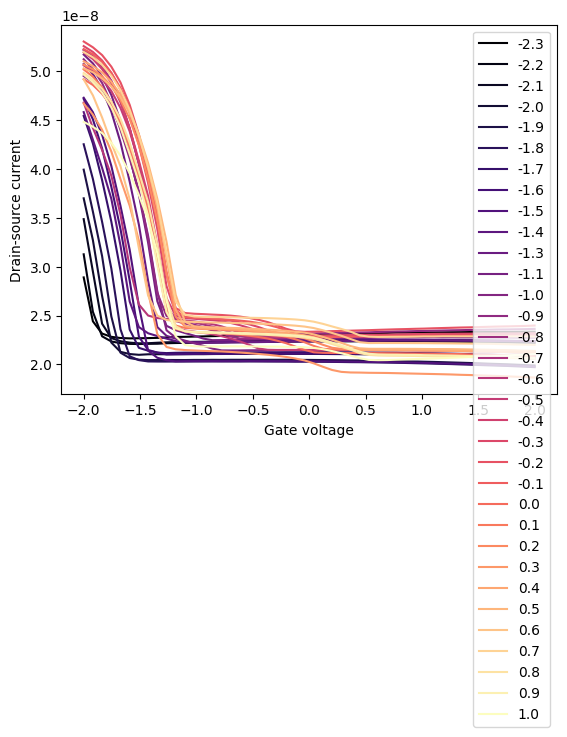

In [56]:
import numpy as np
import matplotlib.pyplot as plt

id_list = range(7, 40)

data = {}
for id in id_list:
    dataset = load_by_run_spec(captured_run_id=id)
    v = dataset.get_parameter_data("gate_voltage")["gate_voltage"]["gate_voltage"]
    i = dataset.get_parameter_data("ds_current")["ds_current"]["ds_current"]
    rv = float(dataset.sample_name.removeprefix("led_reset_voltage_").removesuffix("V_full_swing"))
    data[rv] = {
        "v": v,
        "i": i,
    }

rv_sorted = sorted(data.keys())

# Get magma colormap and generate one color per trace
cmap = plt.get_cmap("magma")
colors = cmap(np.linspace(0, 1, len(rv_sorted)))

for color, rv in zip(colors, rv_sorted):
    plt.plot(data[rv]["v"], data[rv]["i"], label=rv, color=color)

plt.legend()
plt.xlabel("Gate voltage")
plt.ylabel("Drain-source current")
plt.show()


{'ds_current': {'ds_current': array([2.24416729e-08, 2.24528888e-08, 2.24362111e-08, ...,
       3.22627231e-08, 2.72972730e-08, 1.92900138e-08]), 'gate_voltage': array([ 2.        ,  1.99677419,  1.99354839, ..., -2.64516129,
       -2.74193548, -2.83870968]), 'vmin_voltage': array([ 1.83870968,  1.83870968,  1.83870968, ..., -2.83870968,
       -2.83870968, -2.83870968])}}


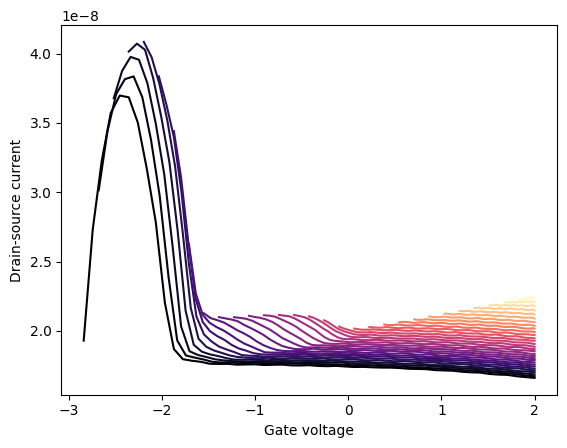

In [30]:
import numpy as np
import matplotlib.pyplot as plt

id = 48

data = {}
dataset = load_by_run_spec(captured_run_id=id)
v = dataset.get_parameter_data("gate_voltage")["gate_voltage"]["gate_voltage"]
i = dataset.get_parameter_data("ds_current")["ds_current"]["ds_current"]
vmin = dataset.get_parameter_data("vmin_voltage")["vmin_voltage"]["vmin_voltage"]
print(dataset.get_parameter_data("ds_current"))
for x in set(vmin):
    data[x] = {
        "v": [],
        "i": [],
    }
for index, x in enumerate(vmin):
    data[x]["v"].append(v[index])
    data[x]["i"].append(i[index])

rv_sorted = sorted(data.keys())

# Get magma colormap and generate one color per trace
cmap = plt.get_cmap("magma")
colors = cmap(np.linspace(0, 1, len(rv_sorted)))

for color, rv in zip(colors, rv_sorted):
    plt.plot(data[rv]["v"], data[rv]["i"], label=rv, color=color)

plt.xlabel("Gate voltage")
plt.ylabel("Drain-source current")
plt.show()
